In [1]:
import torch 
import pandas as pd 
import numpy as np
import os
from matplotlib import pyplot as plt
from gsnn.interpret.utils import plot_edge_importance
from lincs_gsnn.explain.topology import adjust_for_topology
from lincs_gsnn.explain.utils import generate_masked_trajectories

%load_ext autoreload
%autoreload 2


# NON-CONTRASTIVE: Trametinib and DUSP6 

target_gene: 'DUSP6'  

TODO: can we prioritize MTOR/PI3K pathway as the escape mechanism? 


In [2]:
EXP_NAME = 'trametinib_mapk'
ROOT_NAME = 'exp_12'

root = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}'
save_dir = f'/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/{ROOT_NAME}/notebook_{EXP_NAME}/'
os.makedirs(save_dir, exist_ok=True)

data = torch.load(os.path.join(root, 'bionetwork/bionetwork.pt'), weights_only=False)

TARGET_GENE = 'DUSP6'
CELL_LINE_1 = 'MCF7'
DRUG_ID = 'BRD-K12343256'
INCLUSION_THRESHOLD = 0.5 

# Load and aggregated explanations 

In [3]:
from lincs_gsnn.explain.eval import agg_node_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}_node_target__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
node_df = agg_node_scores(path, fill_value=np.nan)
node_df.head() 

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
0,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,0.003551,0.0,0.0
1,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,0.003381,0.0,0.0
2,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,0.003038,0.0,0.0
3,COMPLEX__APC_AXIN1_GSK3B,0.002881,0.0,0.0
4,COMPLEX__APC_CDC20,0.002766,0.0,0.0


In [4]:
from lincs_gsnn.explain.eval import agg_edge_scores

path = f'{root}/non_contrastive_explanation_{EXP_NAME}__{CELL_LINE_1.replace("-", "")}/aggregated_cres.csv'
edge_df = agg_edge_scores(path, fill_value=np.nan)
edge_df.head() 

,source,target,mean_gsnn_score,std_gsnn_score,mean_ig_score,std_ig_score,mean_oc_score,std_oc_score,abs_ig_score,abs_oc_score
0,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,0.002946,0.000704,0.0,0.0,0.0,0.0,0.0,0.0
1,COMPLEX__ACTA1_ACTL6A_ALKBH3_BRD2_BRD8_DMAP1_E...,PROTEIN__H4C6,0.002833,0.000477,0.0,0.0,0.0,0.0,0.0,0.0
2,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,0.002442,0.000306,0.0,0.0,0.0,0.0,0.0,0.0
3,COMPLEX__ACTL6A_ACTL6B_ARID1A_ARID1B_ARID2_PBR...,PROTEIN__TP53,0.003080,0.000143,0.0,0.0,0.0,0.0,0.0,0.0
4,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,COMPLEX__AKT1S1_DEPTOR_MLST8_MTOR_RPTOR,0.003371,0.000158,0.0,0.0,0.0,0.0,0.0,0.0


# Regulator Contributions 

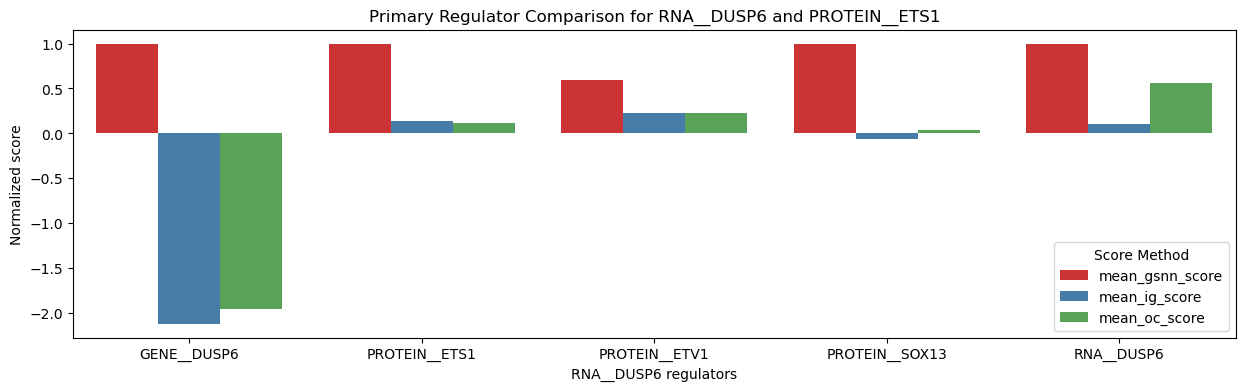

{'gsnn_rank': 4,
 'ig_rank': 4,
 'oc_rank': 3,
 'num_regulators': 5,
 'target_node': 'RNA__DUSP6',
 'expected_regulator': 'PROTEIN__ETS1',
 'expected_direction': 'negative'}

In [5]:
from lincs_gsnn.explain.eval import primary_regulator_comparison

reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'RNA__{TARGET_GENE}', 
                                        expected_regulator='PROTEIN__ETS1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

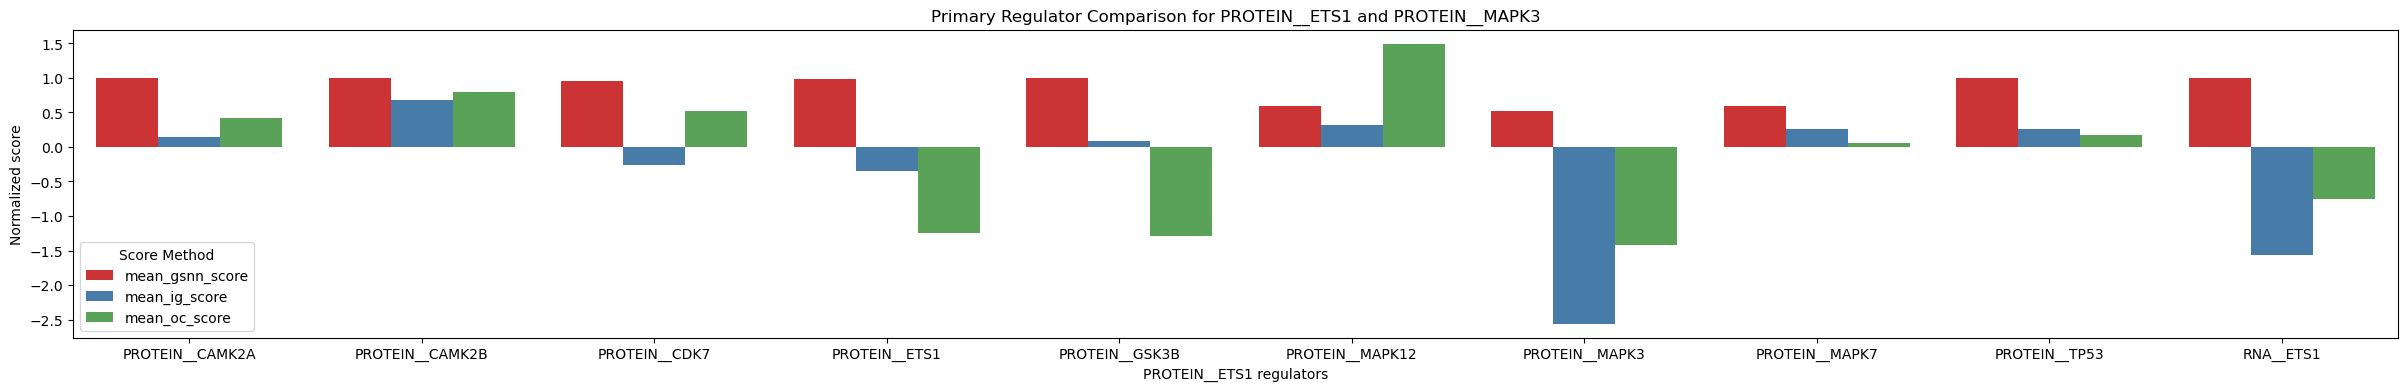

{'gsnn_rank': 10,
 'ig_rank': 1,
 'oc_rank': 1,
 'num_regulators': 10,
 'target_node': 'PROTEIN__ETS1',
 'expected_regulator': 'PROTEIN__MAPK3',
 'expected_direction': 'negative'}

In [6]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__ETS1', 
                                        expected_regulator='PROTEIN__MAPK3', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

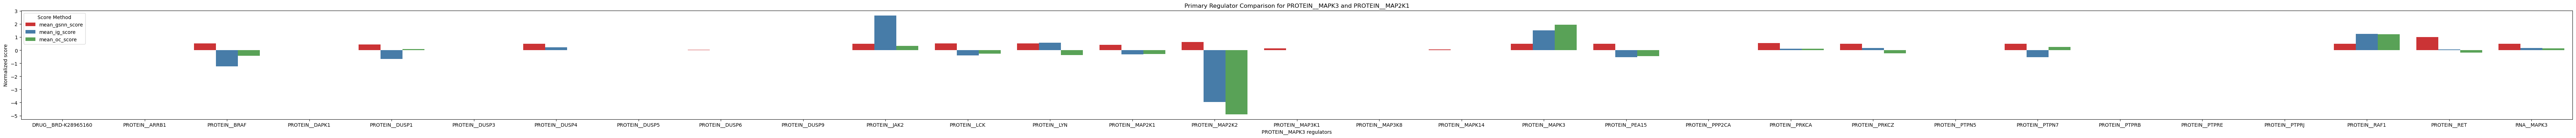

{'gsnn_rank': 16,
 'ig_rank': 7,
 'oc_rank': 5,
 'num_regulators': 31,
 'target_node': 'PROTEIN__MAPK3',
 'expected_regulator': 'PROTEIN__MAP2K1',
 'expected_direction': 'negative'}

In [7]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__MAPK3', 
                                        expected_regulator='PROTEIN__MAP2K1', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

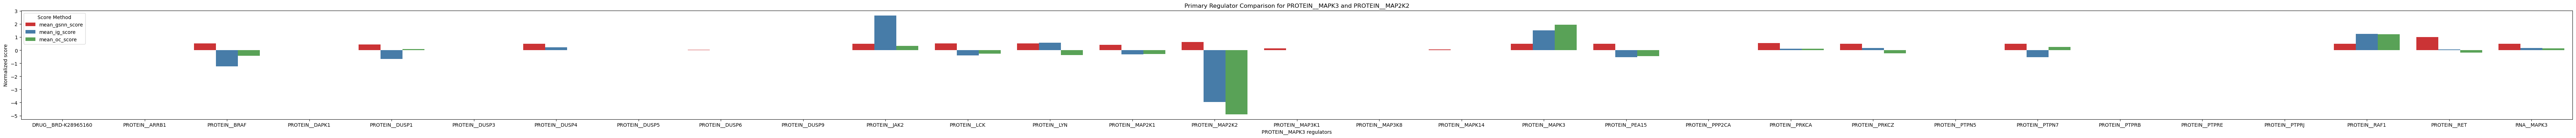

{'gsnn_rank': 2,
 'ig_rank': 1,
 'oc_rank': 1,
 'num_regulators': 31,
 'target_node': 'PROTEIN__MAPK3',
 'expected_regulator': 'PROTEIN__MAP2K2',
 'expected_direction': 'negative'}

In [8]:
reg_dict = primary_regulator_comparison(edge_df=edge_df, 
                                        target_node=f'PROTEIN__MAPK3', 
                                        expected_regulator='PROTEIN__MAP2K2', 
                                        expected_direction='negative', 
                                        plot=True, 
                                        save_dir=None)

reg_dict

# Node ranking comparison 

In [9]:
from lincs_gsnn.explain.eval import data2nx, node_ranking_comparison

G = data2nx(data)

INVOLVED_NODES = ['DRUG__BRD-K12343256', 'PROTEIN__MAP2K1', 'PROTEIN__MAP2K2', 'PROTEIN__MAPK3', 'PROTEIN__ETS1', 'RNA__DUSP6', 'GENE__DUSP6']

mrr_node, node_rank_df = node_ranking_comparison(node_df=node_df, 
                                            G=G, 
                                            target_node=f'RNA__{TARGET_GENE}', 
                                            source_node=f'DRUG__{DRUG_ID}', 
                                            expected_nodes=INVOLVED_NODES, 
                                            expected_direction='negative')


generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


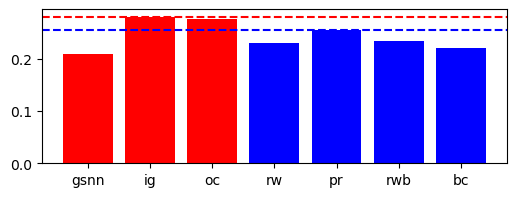

In [10]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_node.columns, mrr_node.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_node[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_node[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


# Edge ranking comparison 

In [11]:
from lincs_gsnn.explain.eval import edge_ranking_comparison

EXPECTED_EDGES = pd.DataFrame({'source': ['DRUG__BRD-K12343256', 'DRUG__BRD-K12343256', 'PROTEIN__MAP2K1', 'PROTEIN__MAP2K2', 'PROTEIN__MAPK3', 'PROTEIN__ETS1'], 
                               'target': ['PROTEIN__MAP2K2', 'PROTEIN__MAP2K1', 'PROTEIN__MAPK3', 'PROTEIN__MAPK3', 'PROTEIN__ETS1', 'RNA__DUSP6']})

mrr_edge, edge_rank_df = edge_ranking_comparison(edge_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_edges=EXPECTED_EDGES)

edge_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...


source,target,gsnn_rank,ig_rank,oc_rank,rw_rank,pr_rank,rwb_rank,bc_rank
DRUG__BRD-K12343256,PROTEIN__MAP2K1,12,53,30,4,4,3,4
DRUG__BRD-K12343256,PROTEIN__MAP2K2,24,26688,2,5,5,27,9
PROTEIN__ETS1,RNA__DUSP6,35,26733,26725,62,49,27,2
PROTEIN__MAP2K1,PROTEIN__MAPK3,584,207,187,3,3,27,9
PROTEIN__MAP2K2,PROTEIN__MAPK3,134,12,4,1,1,22735,9
PROTEIN__MAPK3,PROTEIN__ETS1,188,2,31,10,9,22735,4


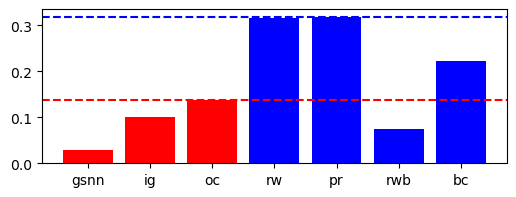

In [12]:
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_edge.columns, mrr_edge.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_edge[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_edge[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


## Path ranking comparison 

In [13]:
from lincs_gsnn.explain.eval import path_ranking_comparison

EXPECTED_PATHS = [
                  'MAP2K1 -> MAPK3 -> ETS1 -> DUSP6', 
                  'MAP2K2 -> MAPK3 -> ETS1 -> DUSP6',
                  ]

mrr_path, path_rank_df = path_ranking_comparison(path_df=edge_df, 
                                                G=G, 
                                                source_node=f'DRUG__{DRUG_ID}', 
                                                target_node=f'GENE__{TARGET_GENE}', 
                                                expected_paths=EXPECTED_PATHS, 
                                                expected_direction='negative', 
                                                max_path_length=6)

path_rank_df 

generating random walk baseline...
generating pagerank baseline...
generating rw-betweenness baseline...
generating betweenness centrality baseline...
adding edge attributes to G...
scoring paths (product) ...
scoring paths (sum) ...
scoring paths (mean) ...


,path_short,mean_gsnn_score_product_rank,mean_ig_score_sum_rank,mean_oc_score_sum_rank,rw_score_sum_rank,pr_score_sum_rank,rwb_score_sum_rank,bc_score_sum_rank
2,MAP2K2 -> MAPK3 -> ETS1 -> DUSP6,20.0,1.0,4.0,1.0,1.0,27.0,5.0
15,MAP2K1 -> MAPK3 -> ETS1 -> DUSP6,26.0,2.0,18.0,14.0,14.0,13.0,1.0


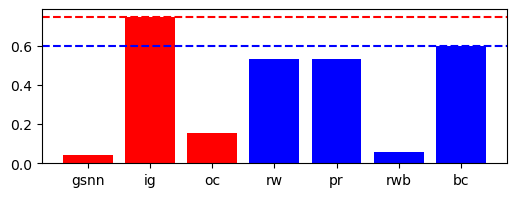

In [14]:
mrr_path = mrr_path.rename(columns={'mean_gsnn_score_product': 'gsnn', 
                                    'mean_ig_score_sum': 'ig', 
                                    'mean_oc_score_sum': 'oc', 
                                    'rw_score_sum': 'rw', 
                                    'pr_score_sum': 'pr', 
                                    'rwb_score_sum': 'rwb', 
                                    'bc_score_sum': 'bc'})
plt.figure(figsize=(6, 2)) 
plt.bar(mrr_path.columns, mrr_path.values[0], color=['r','r','r', 'b', 'b', 'b', 'b']) 
plt.axhline(mrr_path[['gsnn', 'ig', 'oc']].values.ravel().max(), color='r', linestyle='--')
plt.axhline(mrr_path[['rw', 'pr', 'rwb', 'bc']].values.ravel().max(), color='b', linestyle='--')
plt.show() 


---
# Subgraph Explanation Plot 
---

In [15]:
FILTER_TO_DRUG = False
TARGET_NAME = f'RNA__{TARGET_GENE}'
DRUG_NAME = f'DRUG__{DRUG_ID}'

TOP_N_NODES = 75
REMOVE_CELL___EDGES = True
REMOVE_GENE___EDGES = True
PROB_FILTER_THRESH = 0.0

CLIP_SCORE = True
CLIP_VALUE = 10

SCALE_SCORE = True
MIN_SCORE = -1
MAX_SCORE = 1

FILTER_BY_SCORE = 'abs_ig_score'
COLOR_BY_SCORE = 'mean_ig_score' # options: 'mean_ig_score', 'mean_oc_score', 'mean_gsnn_score'\

FIGSIZE = (13,11)
INTERACTIVE = False

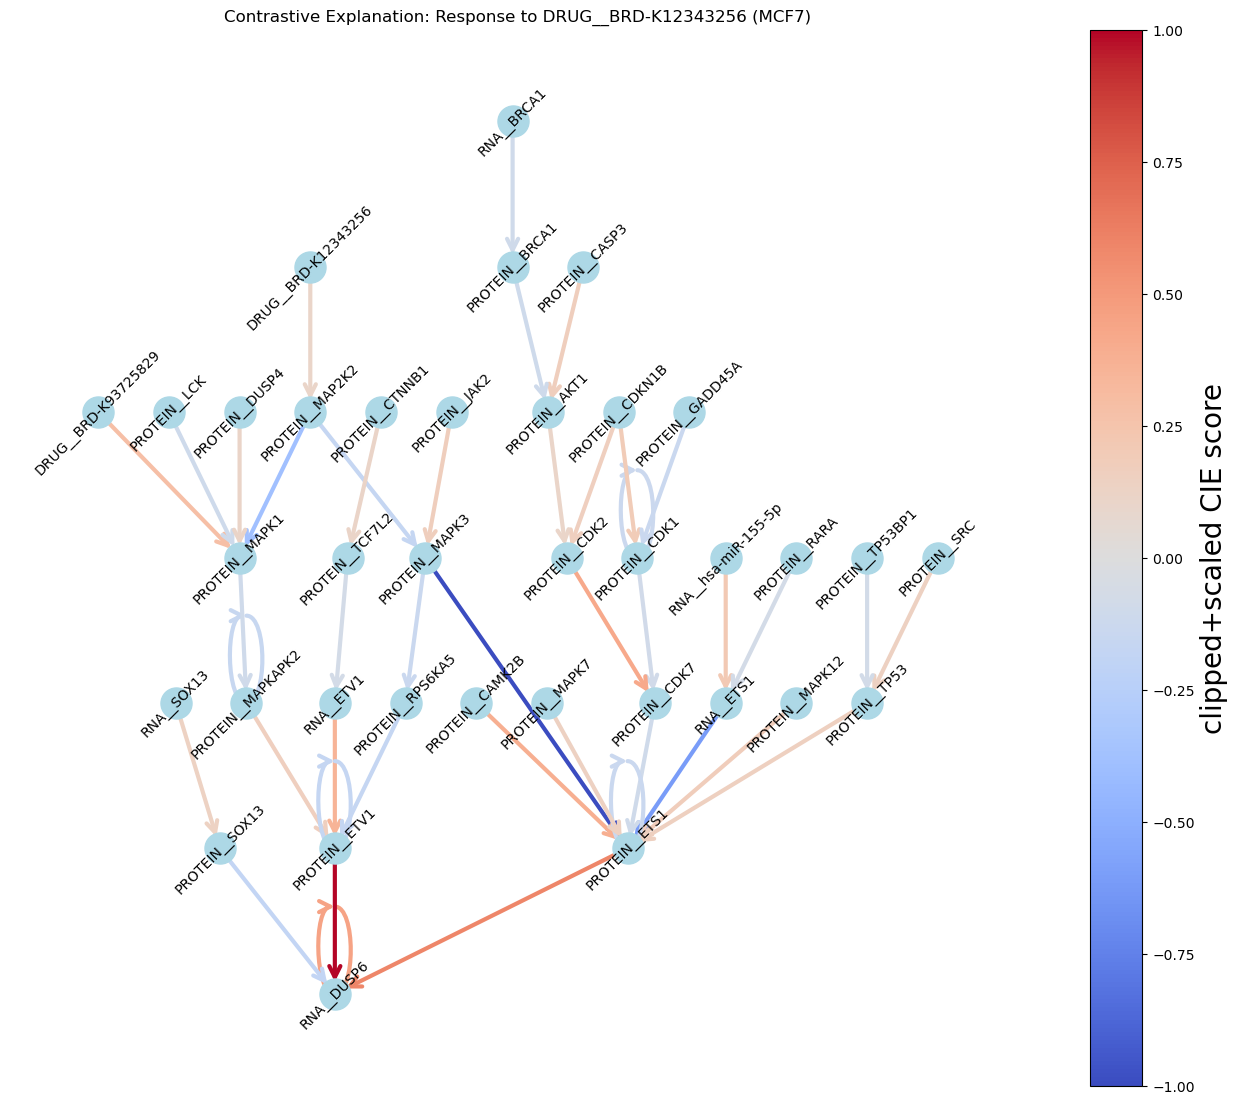

In [16]:
ccres = edge_df.assign(**{'score': lambda x: x[COLOR_BY_SCORE],
                                        'abs_ig_score': lambda x: np.abs(x.mean_ig_score),
                                        'abs_oc_score': lambda x: np.abs(x.mean_oc_score)})[['source', 'target', 'score', FILTER_BY_SCORE]]

if REMOVE_CELL___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('LINE__') | x.target.str.contains('LINE__'))]

if REMOVE_GENE___EDGES: 
    ccres = ccres[lambda x: ~(x.source.str.contains('GENE__') | x.target.str.contains('GENE__'))]

ccres = ccres[ccres[FILTER_BY_SCORE] > PROB_FILTER_THRESH]

ccres = ccres.sort_values(by=FILTER_BY_SCORE, ascending=False).head(TOP_N_NODES)

# SCALING FOR COLOR DISPLAY
if CLIP_SCORE: 
    ccres = ccres.assign(score = lambda x: x.score.values.clip(-CLIP_VALUE, CLIP_VALUE))

if SCALE_SCORE:
    # Scale by absolute max so 0 stays at 0 and signs are preserved
    abs_max = ccres.score.abs().max()
    ccres.loc[ccres.score < 0, 'score'] = ccres.loc[ccres.score < 0, 'score'] / np.abs(ccres.loc[ccres.score < 0, 'score'].min())
    ccres.loc[ccres.score > 0, 'score'] = ccres.loc[ccres.score > 0, 'score'] / np.abs(ccres.loc[ccres.score > 0, 'score'].max())

if INTERACTIVE: 
    figsize = (10, 10)
else: 
    figsize = FIGSIZE

plot_edge_importance(ccres, 
                     figsize=figsize, 
                     leafs=[TARGET_NAME], 
                     roots=[DRUG_NAME] if FILTER_TO_DRUG else None,
                     title=f'Contrastive Explanation: Response to {DRUG_NAME} ({CELL_LINE_1})',
                     interactive=INTERACTIVE, 
                     save=f'{save_dir}/explanation_subgraph_plot_non_interactive_{EXP_NAME}.png',
                     dpi=300, 
                     colorbar_label='clipped+scaled CIE score')



# Resistance pathways 

PI3K, MTOR 

In [17]:
[x.split('__')[1] for x in node_df.sort_values(by='mean_ig_score', ascending=False).head(25).node.values]

['CDK2',
 'E2F2',
 'CREB1',
 'PDPK1',
 'ETV1',
 'ETV1',
 'HSP90AA1',
 'CASP3',
 'MAPK14',
 'SOX13',
 'CREB1',
 'PRKCQ',
 'MAPK12',
 'PTPN7',
 'AURKC',
 'CREBBP',
 'PLK1',
 'GSK3B',
 'CAMK2A',
 'BIRC2',
 'EGFR',
 'AURKA',
 'LYN',
 'PARP1',
 'CDK9']

In [18]:
node_df.sort_values(by='mean_ig_score', ascending=False).head(10)

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
1620,PROTEIN__CDK2,0.983698,0.082735,0.468164
1797,PROTEIN__E2F2,0.504803,0.082235,0.258927
3562,RNA__CREB1,0.500576,0.080798,0.357561
2559,PROTEIN__PDPK1,0.501527,0.078953,0.187145
1872,PROTEIN__ETV1,0.999167,0.078749,-0.174189
3766,RNA__ETV1,0.831603,0.074043,0.247621
2065,PROTEIN__HSP90AA1,0.509306,0.067270,0.294933
1545,PROTEIN__CASP3,0.515209,0.065158,0.126790
2304,PROTEIN__MAPK14,0.539415,0.063974,0.136098
2940,PROTEIN__SOX13,0.512983,0.061304,0.113422


In [19]:
node_df.sort_values(by='mean_oc_score', ascending=False).head(10)

,node,mean_gsnn_score,mean_ig_score,mean_oc_score
1620,PROTEIN__CDK2,0.983698,0.082735,0.468164
2066,PROTEIN__HSP90AB1,0.493401,0.018350,0.396938
2029,PROTEIN__HDAC6,0.504569,0.019644,0.366538
3562,RNA__CREB1,0.500576,0.080798,0.357561
2011,PROTEIN__GSK3B,0.999119,0.038685,0.324223
2065,PROTEIN__HSP90AA1,0.509306,0.067270,0.294933
4626,RNA__PRKCQ,0.500622,0.049405,0.284109
1797,PROTEIN__E2F2,0.504803,0.082235,0.258927
1687,PROTEIN__CREB1,0.498962,0.055914,0.254785
3766,RNA__ETV1,0.831603,0.074043,0.247621


# Masking impact on trajectories 

[PROTEIN__ETS1] - sample 0
[PROTEIN__FOXO3] - sample 0
[RNA__hsa-miR-125b] - sample 0
[PROTEIN__MTOR] - sample 0


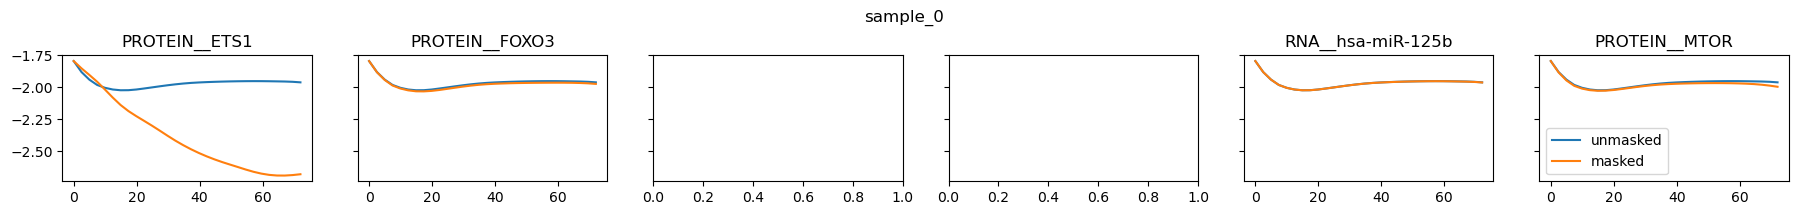

In [20]:
sample_ids = [0] 
root_gsnn = root 
root_traj = '/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-traj/runs/exp/default_v03/output/'

# Given a condition (set of dxdt obs within a condition), what edges are necessary to maintain the predicted values?

drug = DRUG_ID
dose = 10.0

genes_to_remove = ['PROTEIN__ETS1', 'PROTEIN__FOXO3', 'RNA__hsa-miR-181a-5p', 'RNA__hsa-miR-101*', 'RNA__hsa-miR-125b', 'PROTEIN__MTOR']

target_gene = f'GENE__{TARGET_GENE}'

t = torch.linspace(0, 72, 30) # num integration steps 

################################################################################################################
################################################################################################################


res_all ={} 
for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 
    res_masked = {}
    for sample_ix in sample_ids:
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x1_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=CELL_LINE_1.replace('-', ''), drug=drug, dose=dose, t=t, method='dopri5', tol=1e-3)
        res_masked[sample_id] = {f'{CELL_LINE_1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{CELL_LINE_1}_all': x1_t_hat}

    res_all[remove_name] = res_masked 
    print() 


################################################################################################################
################################################################################################################

for sample_ix in sample_ids: 
    sample_id_ = f'sample_{sample_ix}'
    f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 2), sharey=True)
    for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 
        if remove_name not in data.node_names_dict['function']: 
            continue 
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_all'], label='unmasked')
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_masked_{remove_name}'], label='masked')
        ax.set_title(remove_name)
    ax.legend()
    plt.tight_layout()
    plt.suptitle(f'{sample_id_}', y=1.05)
    plt.show() 


[PROTEIN__ETS1] - sample 0
[PROTEIN__FOXO3] - sample 0
[RNA__hsa-miR-125b] - sample 0
[PROTEIN__MTOR] - sample 0


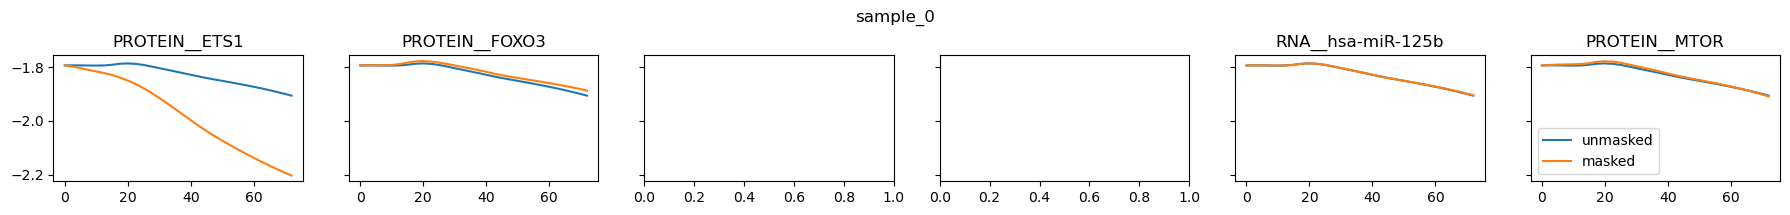

In [21]:
dose = 0.0

################################################################################################################
################################################################################################################


res_all ={} 
for remove_name in genes_to_remove: 
    if remove_name not in data.node_names_dict['function']: 
        continue 
    res_masked = {}
    for sample_ix in sample_ids:
        print(f'[{remove_name}] - sample {sample_ix}', end='\r')
        sample_id = f'sample_{sample_ix}'
        x1_t_hat, x1_t_hat_nm = generate_masked_trajectories(root_gsnn, root_traj, sample_id=sample_id, target_gene=target_gene, remove_name=remove_name, cell=CELL_LINE_1.replace('-', ''), drug=drug, dose=dose, t=t, method='dopri5', tol=1e-3)
        res_masked[sample_id] = {f'{CELL_LINE_1}_masked_{remove_name}': x1_t_hat_nm, 
                                f'{CELL_LINE_1}_all': x1_t_hat}

    res_all[remove_name] = res_masked 
    print() 


################################################################################################################
################################################################################################################

for sample_ix in sample_ids: 
    sample_id_ = f'sample_{sample_ix}'
    f,axes = plt.subplots(1, len(genes_to_remove), figsize=(3*len(genes_to_remove), 2), sharey=True)
    for jj, (ax, remove_name) in enumerate(zip(axes, genes_to_remove)): 
        if remove_name not in data.node_names_dict['function']: 
            continue 
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_all'], label='unmasked')
        ax.plot(t, res_all[remove_name][sample_id_][f'{CELL_LINE_1}_masked_{remove_name}'], label='masked')
        ax.set_title(remove_name)
    ax.legend()
    plt.tight_layout()
    plt.suptitle(f'{sample_id_}', y=1.05)
    plt.show() 
